Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/kanish/Desktop/NTU/Trimester 1/ML in Finance/Group Project/MH-6805-Team-Project-/venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
40 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/kanish/Desktop/NTU/Trimester 1/ML in Finance/Group Project/MH-6805-Team-Project-/venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kanish/Desktop/NTU/Trimester 1/ML in Finance/Group Project/MH-6805-Team-Project-/venv/l


🔍 Best Hyperparameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': None}
Best CV Score: 0.0003

✅ Model Evaluation Results:
Mean Absolute Error (MAE): 0.0109
Root Mean Squared Error (RMSE): 0.0179
R² Score: 0.3560

Top 10 Important Features:
RSI_14         0.317846
MACD           0.166422
ATR_14         0.140390
MACD_Signal    0.128653
MACD_Hist      0.127825
Volume         0.118865
dtype: float64

📊 Monthly Sector-Level Aggregation:
                   Sector  YearMonth  Actual_Return  Predicted_Return  \
0  Communication Services 2024-10-01       0.002403          0.001856   
1  Communication Services 2024-11-01       0.006467          0.006760   
2  Communication Services 2024-12-01      -0.000560         -0.000484   
3  Communication Services 2025-01-01       0.003199          0.003243   
4  Communication Services 2025-02-01       0.000762          0.000924   

  Actual_Direction Predicted_Direction  
0               up

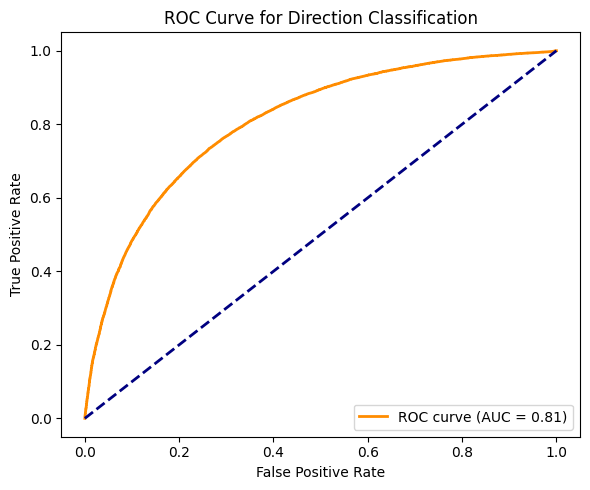

In [1]:
# %% Import Libraries
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, roc_curve, auc
)
import matplotlib.pyplot as plt

# %% Step 1: Load and Clean Data
def load_and_prepare_data(filepath, target_column='Return', date_column='Date'):
    selected_features = ['RSI_14', 'MACD', 'ATR_14', 'MACD_Hist', 'Volume', 'MACD_Signal']
    keep_columns = selected_features + [target_column, date_column, 'Sector']

    df = pd.read_csv('indicators_daily.csv')
    df = df[[col for col in df.columns if col in keep_columns]]

    if date_column in df.columns:
        df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
        df.dropna(subset=[date_column], inplace=True)

    df.dropna(subset=[target_column], inplace=True)
    return df

# %% Step 2: Encode Categorical Features
def encode_categoricals(df, exclude_columns=None):
    df = df.copy()
    label_encoders = {}
    for col in df.columns:
        if exclude_columns and col in exclude_columns:
            continue
        if df[col].dtype == 'object':
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            label_encoders[col] = le
    return df, label_encoders

# %% Step 3: Tune and Evaluate Random Forest Regressor
def train_evaluate_rf(X_train, y_train, X_test, y_test):
    param_dist = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 10, 20],
        'min_samples_leaf': [2, 5, 10],
        'max_features': ['log2', 'sqrt', 'none']
    }

    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=20,
        scoring='neg_mean_squared_error',
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)

    print("\n🔍 Best Hyperparameters:")
    print(random_search.best_params_)
    print(f"Best CV Score: {-random_search.best_score_:.4f}")

    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\n✅ Model Evaluation Results:")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    return best_model, X_test.columns, y_pred

# %% Step 4: Feature Importance
def show_feature_importance(model, feature_names, top_n=10):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    print(f"\nTop {top_n} Important Features:")
    print(importances.sort_values(ascending=False).head(top_n))

# %% Step 5: Aggregate Monthly Returns by Sector
def aggregate_monthly_returns(df_test, y_test, y_pred):
    df_test = df_test.copy()
    df_test['Actual_Return'] = y_test
    df_test['Predicted_Return'] = y_pred
    df_test['Date'] = pd.to_datetime(df_test['Date'], errors='coerce')
    df_test['YearMonth'] = df_test['Date'].dt.to_period('M')

    monthly_agg = df_test.groupby(['Sector', 'YearMonth'])[['Actual_Return', 'Predicted_Return']].mean().reset_index()
    monthly_agg['YearMonth'] = monthly_agg['YearMonth'].dt.to_timestamp()

    monthly_agg['Actual_Direction'] = np.where(monthly_agg['Actual_Return'] > 0, 'up', 'down')
    monthly_agg['Predicted_Direction'] = np.where(monthly_agg['Predicted_Return'] > 0, 'up', 'down')

    print("\n📊 Monthly Sector-Level Aggregation:")
    print(monthly_agg.head())
    return monthly_agg

# %% Step 6: Save Final Results to CSV
def save_final_results(df_test, y_test, y_pred, output_path='regression_returns_output.csv'):
    final_df = df_test.copy()
    final_df['Actual_Return'] = y_test
    final_df['Predicted_Return'] = y_pred
    final_df['Actual_Direction'] = np.where(y_test > 0, 'up', 'down')
    final_df['Predicted_Direction'] = np.where(y_pred > 0, 'up', 'down')

    final_df = final_df[['Date', 'Sector', 'Actual_Return', 'Predicted_Return', 'Actual_Direction', 'Predicted_Direction'] +
                        [col for col in final_df.columns if col not in ['Date', 'Sector', 'Actual_Return', 'Predicted_Return', 'Actual_Direction', 'Predicted_Direction']]]

    final_df.to_csv(output_path, index=False)
    print(f"\n📁 Final results saved to '{output_path}'")

# %% Step 7: Direction Classification Metrics and ROC Curve
def evaluate_direction_classification(y_test, y_pred):
    actual_direction = np.where(y_test > 0, 1, 0)
    predicted_direction = np.where(y_pred > 0, 1, 0)

    print("\n📊 Directional Classification Report:")
    print(classification_report(actual_direction, predicted_direction, target_names=['down', 'up']))

    print("Confusion Matrix:")
    print(confusion_matrix(actual_direction, predicted_direction))

    fpr, tpr, thresholds = roc_curve(actual_direction, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Direction Classification')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# %% Run Pipeline
if __name__ == "__main__":
    df = load_and_prepare_data(
        filepath='indicators_daily.csv',
        target_column='Return',
        date_column='Date'
    )

    train_start = datetime(2022, 10, 1)
    train_end   = datetime(2024, 9, 30)
    test_start  = datetime(2024, 10, 1)
    test_end    = datetime(2025, 9, 30)

    df_train = df[(df['Date'] >= train_start) & (df['Date'] <= train_end)].copy()
    df_test  = df[(df['Date'] >= test_start) & (df['Date'] <= test_end)].copy()

    feature_columns = ['RSI_14', 'MACD', 'ATR_14', 'MACD_Hist', 'Volume', 'MACD_Signal']
    X_train_encoded, _ = encode_categoricals(df_train[feature_columns])
    X_test_encoded, _  = encode_categoricals(df_test[feature_columns])
    y_train = df_train['Return']
    y_test  = df_test['Return']

    model, feature_names, y_pred = train_evaluate_rf(X_train_encoded, y_train, X_test_encoded, y_test)
    show_feature_importance(model, feature_names)

    monthly_summary = aggregate_monthly_returns(df_test, y_test, y_pred)
    save_final_results(df_test, y_test, y_pred)
    evaluate_direction_classification(y_test, y_pred)


/var/folders/5_/c20qy50s35jdz3bv32kv3lpw0000gn/T/ipykernel_9249/3251016585.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strat_ret = sec_daily.groupby('Date').apply(_avg_selected).rename('strategy').sort_index()


QS window: 2024-11-01 → 2025-10-01
                     strategy  benchmark
Date                                    
2024-11-01 04:00:00 -0.005509  -0.002017
2024-11-04 05:00:00  0.000202  -0.000485
2024-11-05 05:00:00  0.012882   0.012956


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2024-11-01   2024-11-01
End Period                 2025-10-01   2025-10-01
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       100.0%

Cumulative Return          21.2%        21.34%
CAGR﹪                     23.68%       23.84%

Sharpe                     1.41         1.31
Prob. Sharpe Ratio         90.87%       88.59%
Smart Sharpe               1.36         1.26
Sortino                    2.09         1.86
Smart Sortino              2.0          1.78
Sortino/√2                 1.48         1.31
Smart Sortino/√2           1.42         1.26
Omega                      1.32         1.32

Max Drawdown               -13.89%      -13.88%
Max DD Date                2025-04-08   2025-04-08
Max DD Period Start        2025-02-19   2025-02-19
Max DD Period End          2025-05-12   2025-05-14
Longest DD Days            82           84
Vola

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2025-02-19,2025-04-08,2025-05-14,84,-13.876680,-12.375557
2,2024-12-02,2025-01-13,2025-01-22,52,-7.075498,-6.623960
3,2025-01-24,2025-01-27,2025-02-12,20,-5.953755,-3.551215
4,2025-05-20,2025-05-22,2025-05-30,11,-1.842282,-1.549902
5,2025-07-28,2025-08-01,2025-08-06,10,-1.442174,-1.094564


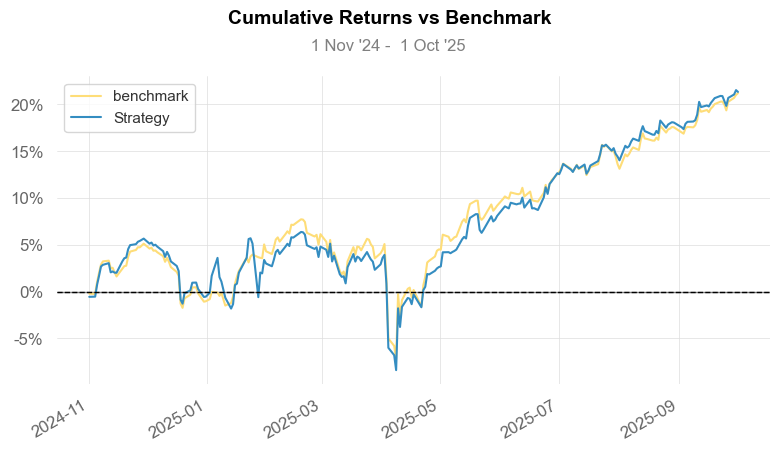

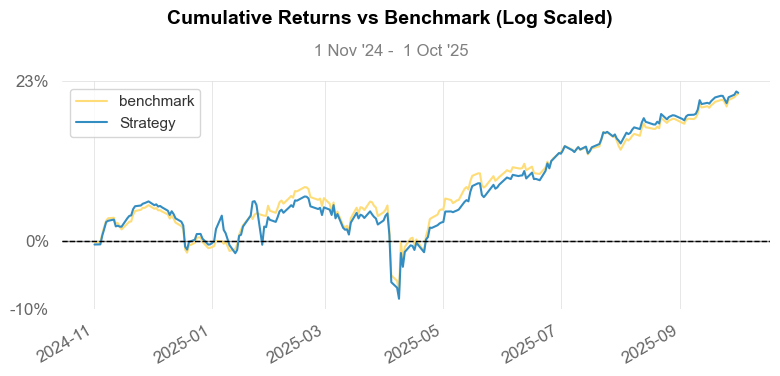

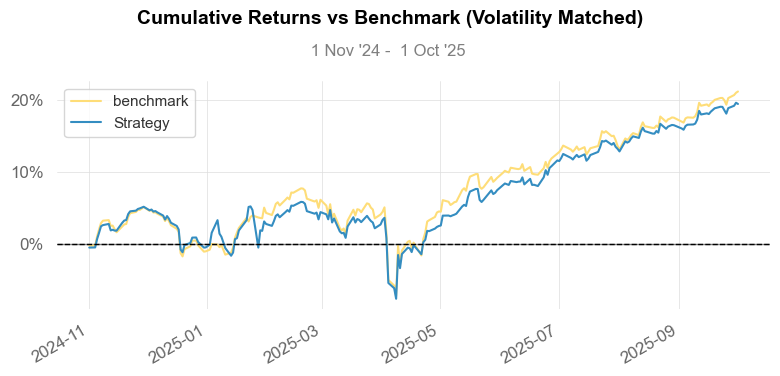

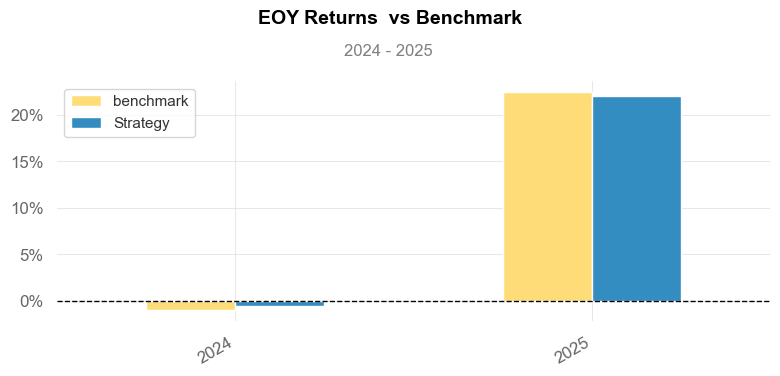

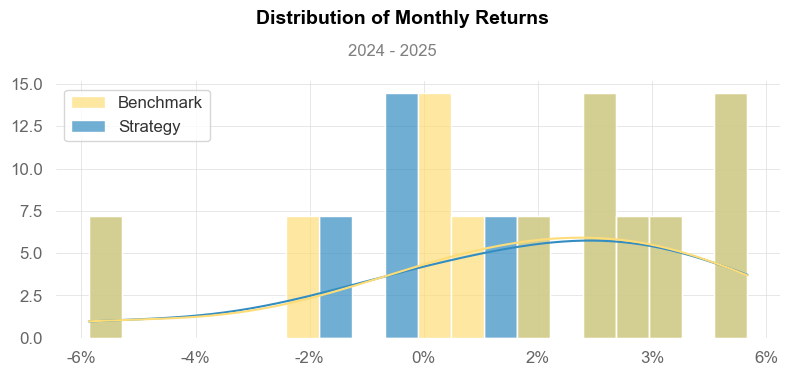

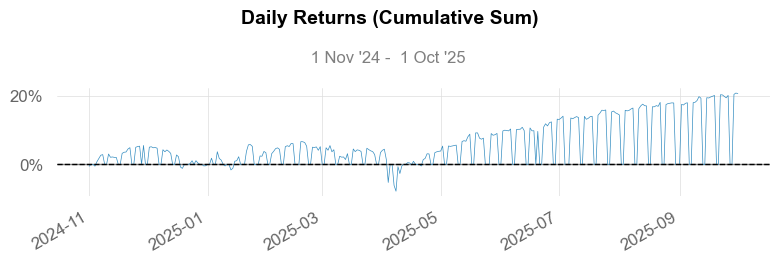

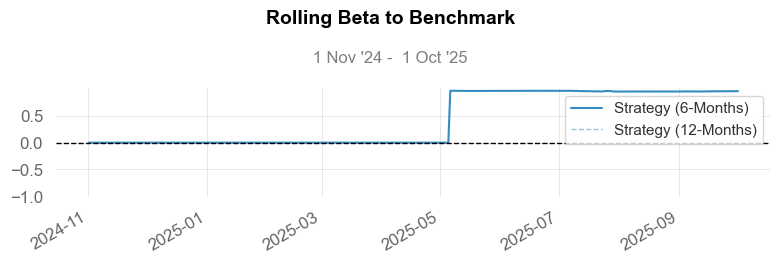

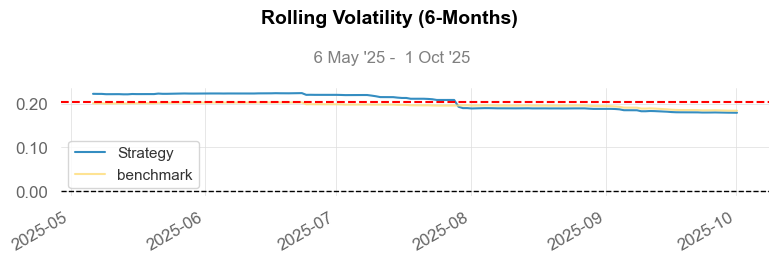

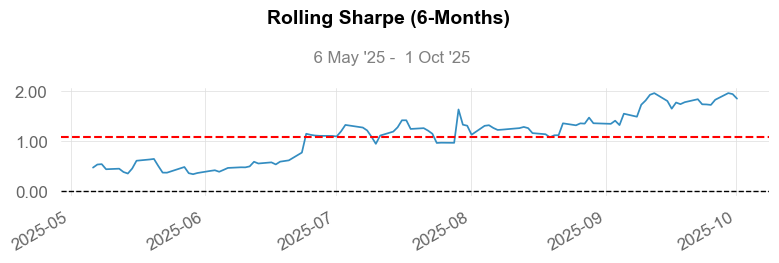

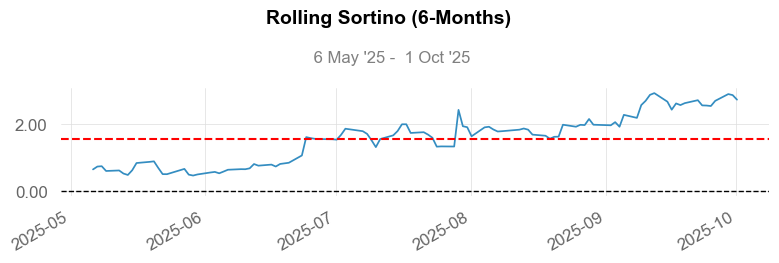

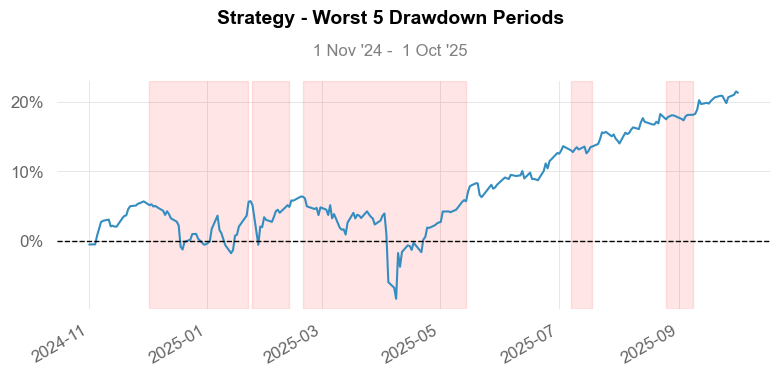

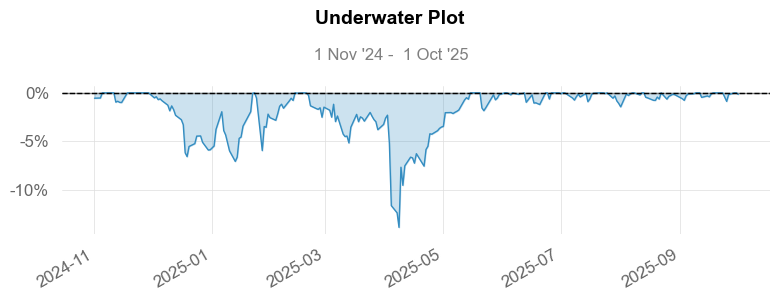

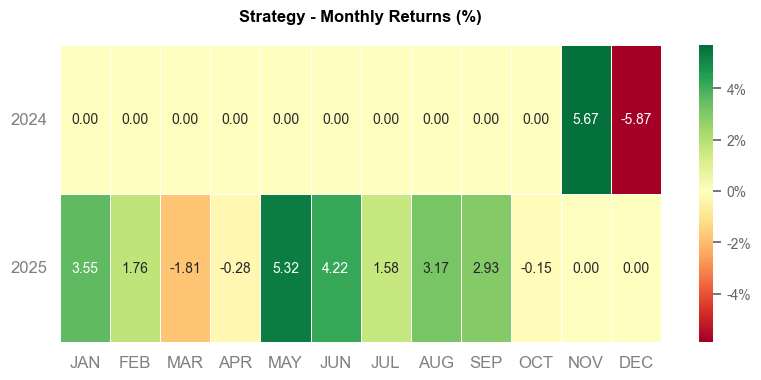

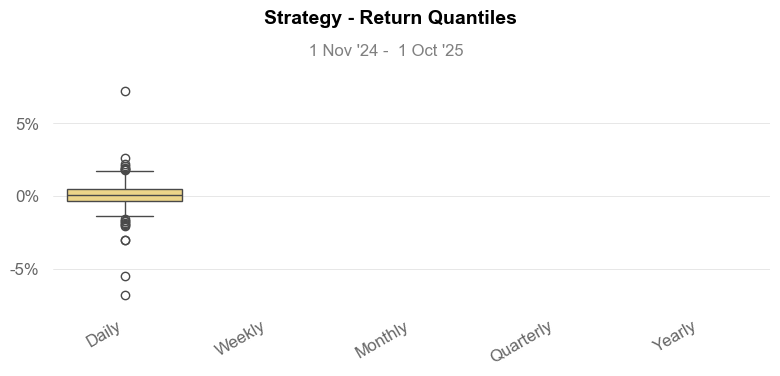

✓ QuantStats complete. Open 'tearsheet_rf_strategy.html' for the full report.


In [2]:
# === QuantStats tear sheet from RF monthly signals (next-month rebalancing) ===
import numpy as np
import pandas as pd

# --- 0) Preconditions ---
# We assume the previous cell defined:
#   df .............. full daily dataframe with columns: ['Date','Sector','Return', ...]
#   monthly_summary . output of aggregate_monthly_returns(df_test, y_test, y_pred)
#                      with columns: ['Sector','YearMonth','Actual_Return','Predicted_Return',
#                                     'Actual_Direction','Predicted_Direction']
assert 'df' in globals(), "Need the full dataframe `df` from the previous cell."
assert 'monthly_summary' in globals(), "Run `aggregate_monthly_returns` to produce `monthly_summary` first."

# --- 1) Build monthly signals and SHIFT to trade NEXT month (avoid look-ahead) ---
sig = monthly_summary.copy()
sig['Month'] = pd.PeriodIndex(sig['YearMonth'], freq='M')
sig['Signal'] = (sig['Predicted_Direction'] == 'up').astype(int)
sig = sig[['Sector', 'Month', 'Signal']].copy()

# trade in t+1 using info from t
sig['TradeMonth'] = sig['Month'] + 1
signals_for_merge = sig[['Sector', 'TradeMonth', 'Signal']].rename(columns={'TradeMonth': 'Month'})

# --- 2) Build DAILY sector equal-weight returns over the full test window inferred from signals ---
test_start = signals_for_merge['Month'].min().to_timestamp(how='start')
test_end   = signals_for_merge['Month'].max().to_timestamp(how='end')

df2 = df.copy()
df2['Date'] = pd.to_datetime(df2['Date'])
daily = df2[(df2['Date'] >= test_start) & (df2['Date'] <= test_end)].dropna(subset=['Return']).copy()

# sector-day equal-weight return
sec_daily = (daily.groupby(['Date','Sector'])['Return']
                  .mean()
                  .reset_index(name='SecRet'))
sec_daily['Month'] = sec_daily['Date'].dt.to_period('M')

# --- 3) Attach monthly (t+1) signals to each sector-day within that trading month ---
sec_daily = sec_daily.merge(signals_for_merge, on=['Sector','Month'], how='left')
sec_daily['Signal'] = sec_daily['Signal'].fillna(0).astype(int)

# --- 4) Strategy & Benchmark daily returns ---
def _avg_selected(g):
    n = g['Signal'].sum()
    if n <= 0:
        return 0.0
    return g.loc[g['Signal'] == 1, 'SecRet'].mean()

strat_ret = sec_daily.groupby('Date').apply(_avg_selected).rename('strategy').sort_index()
bench_ret = (sec_daily.groupby('Date')['SecRet'].mean().rename('benchmark').sort_index())

print(f"QS window: {strat_ret.index.min().date()} → {strat_ret.index.max().date()}")
print(pd.concat([strat_ret.head(3), bench_ret.head(3)], axis=1))

# --- 5) QuantStats tear sheet (inline + HTML) ---
try:
    import quantstats as qs
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "quantstats"])
    import quantstats as qs

# ensure DatetimeIndex
strat_ret.index = pd.DatetimeIndex(strat_ret.index)
bench_ret.index = pd.DatetimeIndex(bench_ret.index)

# Inline summary (and save full HTML report)
qs.reports.html(
    strat_ret,
    benchmark=bench_ret,
    title="RF Directional Strategy (Next-Month, Long-Only)",
    output="tearsheet_rf_strategy.html",
    figfmt="png"
)

qs.reports.full(
    strat_ret,
    benchmark=bench_ret,
    title="RF Directional Strategy (Next-Month, Long-Only)",
    display=True,
    output=None
)

print("✓ QuantStats complete. Open 'tearsheet_rf_strategy.html' for the full report.")